# Compare Two-Stage Q-Learning Performance

This notebook compares the performance of Two-Stage Q-Learning vs standard Q-Learning approaches by fetching metrics from Azure ML experiments using MLflow.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import logging

from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy import stats
# Enable inline plotting
%matplotlib inline

In [3]:
# Connect to Azure ML Workspace using SDK v2 and setup MLflow
# The workspace will be loaded from config.json file if available, or you can specify parameters
try:
    # Using DefaultAzureCredential for authentication
    credential = DefaultAzureCredential()
    credential.get_token("https://management.azure.com/.default")
    # Create ML Client from config.json
    ml_client = MLClient.from_config(credential=credential)
    print(f"Connected to workspace: {ml_client.workspace_name}")
    print(f"Subscription: {ml_client.subscription_id}")
    print(f"Resource group: {ml_client.resource_group_name}")

except Exception as e:
    print(f"Error connecting to workspace: {e}")
    raise

# Set up MLflow tracking URI for Azure ML
tracking_uri = ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri
mlflow.set_tracking_uri(tracking_uri)
print(f"✓ MLflow tracking URI set successfully to {mlflow.get_tracking_uri()}")

Found the config file in: .\config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


Connected to workspace: mlw-research-pro-003
Subscription: 706e41e6-9c7a-47c4-b231-c6e8897cfb63
Resource group: rg-research-pro-003
✓ MLflow tracking URI set successfully to azureml://westeurope.api.azureml.ms/mlflow/v2.0/subscriptions/706e41e6-9c7a-47c4-b231-c6e8897cfb63/resourceGroups/rg-research-pro-003/providers/Microsoft.MachineLearningServices/workspaces/mlw-research-pro-003


In [8]:
experiment = mlflow.get_experiment_by_name("SIRS-Q-Learning")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], order_by=["start_time DESC"])
runs = runs[
    (runs["start_time"] >= "2026-04-14 22:12:00") & (runs["start_time"] <= "2026-04-15 06:00:00")
]  # Filter runs by start time

In [9]:
client = mlflow.tracking.MlflowClient()

In [14]:
def fetch_metric_history(client: mlflow.tracking.MlflowClient, run_id: str, key: str):
    try:
        history = client.get_metric_history(run_id, key)
        logging.info(f"Fetching {len(history)} entries for run_id {run_id} and key {key}")
        history = [metric.to_dictionary() for metric in history]
    except Exception as e:
        logging.exception(f"Error fetching metric history for run_id {run_id} and key {key}: {e}")
        history = []
    history = pd.DataFrame(history)
    return history

In [ ]:
metric_name = "log_mean_relative_error"

def compute_mean_and_ci(df, confidence=0.95):
    """Compute mean and 95% CI per step across runs."""
    # TODO: Update formula if x=(x1,...,xN), then the interval is mean(x) - 1.96*quasisd(x)/sqrt(n) and mean(x) + 1.96*quasisd(x)/sqrt(n)
    grouped = df.groupby('step')['value']
    mean = grouped.mean()
    sem = grouped.sem()
    n = grouped.count()
    h = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean.index, mean.values, (mean - h).values, (mean + h).values

def fetch_metrics_for_runs(runs_subset):
    """Fetch log MRE metric history for a subset of runs and return as DataFrame with learn_mode."""
    result = pd.DataFrame()
    for run in tqdm(runs_subset.itertuples(), total=len(runs_subset)):
        m = fetch_metric_history(client, run.run_id, metric_name)
        m["run_id"] = run.run_id
        result = pd.concat([result, m], ignore_index=True)
    result = result.merge(runs_subset[["run_id", "tags.learn_mode"]], on="run_id", how="left")
    return result

## Overall Log MRE — Size = 5

In [12]:
runs_5 = runs[runs["params.size"] == "5"]
metrics_5 = fetch_metrics_for_runs(runs_5)

complete_5 = metrics_5[metrics_5["tags.learn_mode"] == "complete"]
two_stage_5 = metrics_5[metrics_5["tags.learn_mode"] == "two_stages"]

print(f"Size=5 — Q-learning: {complete_5['run_id'].nunique()} runs | Smart Q-learning: {two_stage_5['run_id'].nunique()} runs")

Fetching 1001 entries for run_id icy_leather_wrh1j8ng1y and key log_mean_relative_error
Fetching 1001 entries for run_id silver_loquat_bqdskhvgny and key log_mean_relative_error
Fetching 1001 entries for run_id plucky_bone_0tzy2qmlyq and key log_mean_relative_error
Fetching 1001 entries for run_id red_pear_xn0sncxt77 and key log_mean_relative_error
Fetching 1001 entries for run_id lucid_pencil_088386tkbh and key log_mean_relative_error
Fetching 1001 entries for run_id salmon_apple_qhfdyn555p and key log_mean_relative_error
Fetching 1001 entries for run_id sad_yacht_znjnrrd9yb and key log_mean_relative_error
Fetching 1001 entries for run_id ashy_kitten_v71wnm4w60 and key log_mean_relative_error
Fetching 1001 entries for run_id hungry_net_5ff100s691 and key log_mean_relative_error
Fetching 1001 entries for run_id quiet_soccer_myt4z3dc1d and key log_mean_relative_error
Fetching 1001 entries for run_id careful_toe_wbrwt0b9ms and key log_mean_relative_error
Fetching 1001 entries for run_id 

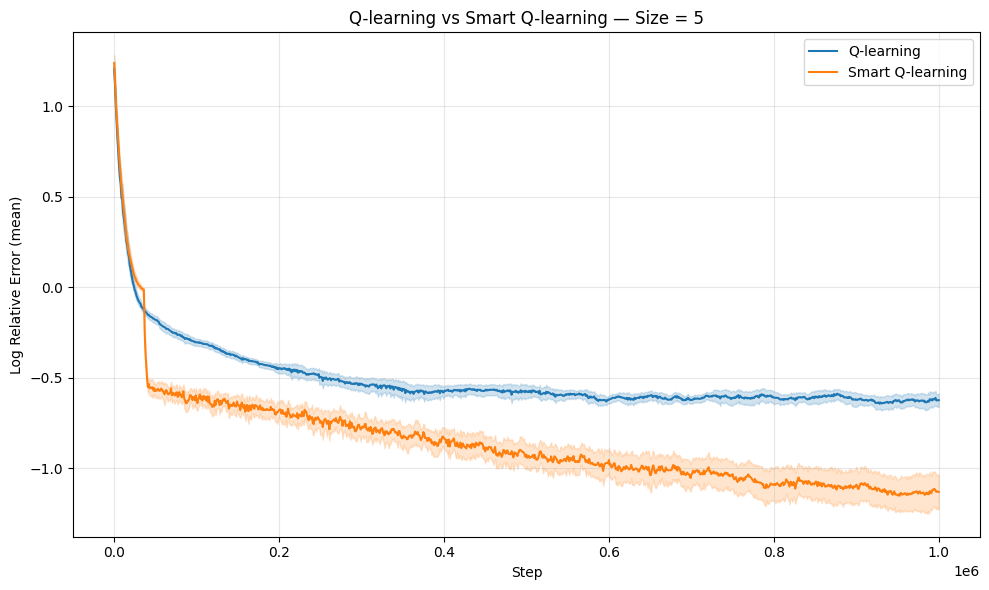

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

if not complete_5.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_5)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_5.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_5)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — Size = 5")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Overall Log MRE — Size = 10

In [16]:
runs_10 = runs[runs["params.size"] == "10"]
metrics_10 = fetch_metrics_for_runs(runs_10)

complete_10 = metrics_10[metrics_10["tags.learn_mode"] == "complete"]
two_stage_10 = metrics_10[metrics_10["tags.learn_mode"] == "two_stages"]

print(f"Size=10 — Q-learning: {complete_10['run_id'].nunique()} runs | Smart Q-learning: {two_stage_10['run_id'].nunique()} runs")

Size=10 — Q-learning: 5 runs | Smart Q-learning: 5 runs


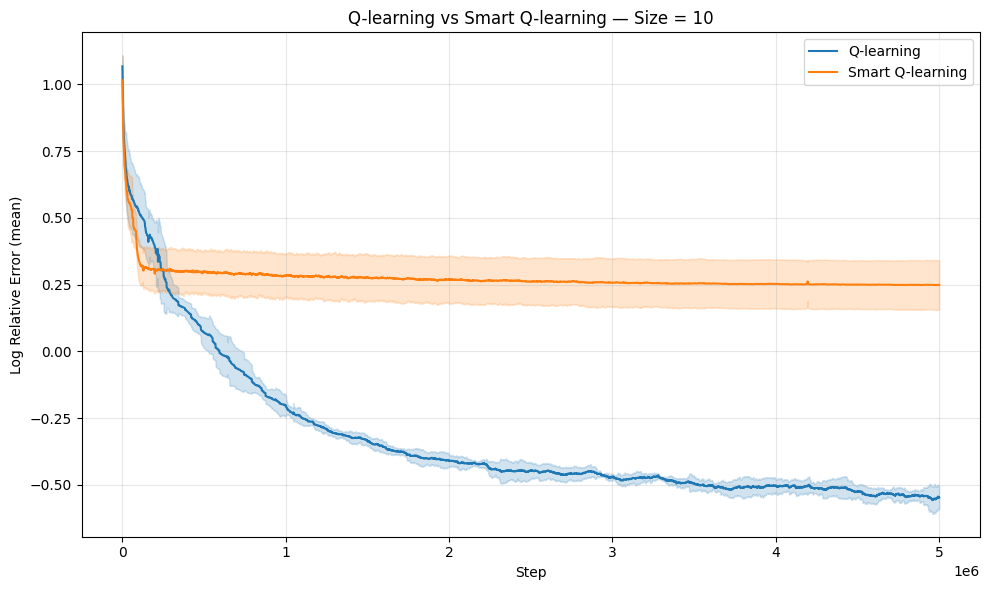

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

if not complete_10.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_10)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_10.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_10)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — Size = 10")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Single-State Log MRE — Size = 5

Load Q checkpoints from local artifact folders and compute log MRE for a specific state $(m_s, m_i)$ over training steps.

In [ ]:
import re
from pathlib import Path

# Artifact folders (one per run)
artifacts_path_complete   = Path("../outputs/runs/dcid.careful_toe_wbrwt0b9ms")
artifacts_path_two_stages = Path("../outputs/runs/dcid.icy_leather_wrh1j8ng1y")

def load_run_state_errors(artifacts_path: Path):
    """
    Load Q_true and all Q checkpoints from a local artifact folder.
    Returns dict {step: log_mre_matrix (S+1, S+1)}.
    """
    q_true_files = list((artifacts_path / "Q_true").glob("*.npy"))
    assert q_true_files, f"No Q_true .npy found in {artifacts_path / 'Q_true'}"
    Q_true = np.load(q_true_files[0])           # (S+1, S+1, A)
    safe_Q_true = np.where(Q_true != 0, Q_true, np.nan)

    results = {}
    for chkpt_dir in sorted(artifacts_path.glob("chkpt_*")):
        npy_files = list(chkpt_dir.glob("*.npy"))
        if not npy_files:
            continue
        match = re.search(r'_(\d+)\.npy$', npy_files[0].name)
        if not match:
            continue
        step = int(match.group(1))
        Q_ckpt = np.load(npy_files[0])          # (S+1, S+1, A)
        rel_err = np.abs(safe_Q_true - Q_ckpt) / np.abs(safe_Q_true)
        mre = np.nanmean(rel_err, axis=2)        # (S+1, S+1)
        results[step] = np.where(mre > 0, np.log10(mre), np.nan)

    return dict(sorted(results.items()))

errors_complete   = load_run_state_errors(artifacts_path_complete)
errors_two_stages = load_run_state_errors(artifacts_path_two_stages)
print(f"Q-learning     : {len(errors_complete)} checkpoints")
print(f"Smart Q-learning: {len(errors_two_stages)} checkpoints")

C:\Users\ccarballo\AppData\Local\Temp\ipykernel_18324\1290692629.py:29: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)        # (S+1, S+1)


Q-learning     : 1000 checkpoints
Smart Q-learning: 1000 checkpoints


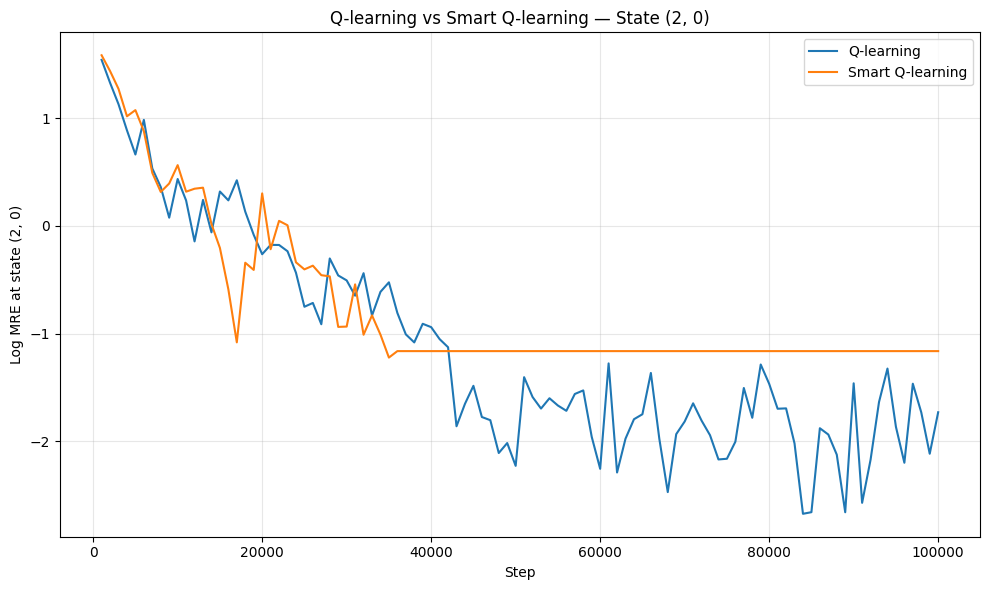

In [58]:
# Choose the state to plot
m_s, m_i = 2, 0

steps_c = sorted(errors_complete.keys())
steps_t = sorted(errors_two_stages.keys())

log_mre_c = [errors_complete[s][m_s, m_i]   for s in steps_c]
log_mre_t = [errors_two_stages[s][m_s, m_i] for s in steps_t]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(steps_c[:100], log_mre_c[:100], label="Q-learning",      color="tab:blue")
ax.plot(steps_t[:100], log_mre_t[:100], label="Smart Q-learning", color="tab:orange")
ax.set_xlabel("Step")
ax.set_ylabel(f"Log MRE at state ({m_s}, {m_i})")
ax.set_title(f"Q-learning vs Smart Q-learning — State ({m_s}, {m_i})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()